In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from lightgbm import LGBMClassifier

# Cargar el mismo dataset y features usados en el cuaderno 3
df = pd.read_csv("../datos/procesados/dataset_modelo.csv", parse_dates=["end"])
features = pd.read_csv("../salidas/features_modelo.csv")["0"].tolist()

# Reconstruir features temporales igual que en el cuaderno 3
df = df.sort_values(["ticker", "end"])
vars_momentum = ["fcf_operativo", "utilidad_neta", "caja", "burn_rate", "margen_bruto", "ingresos"]
vars_rezago   = ["fcf_operativo", "utilidad_neta", "caja", "burn_rate"]

for var in vars_momentum:
    df[f"{var}_cambio"]     = df.groupby("ticker", observed=True)[var].diff()
    df[f"{var}_cambio_pct"] = df.groupby("ticker", observed=True)[var].pct_change()

for var in vars_rezago:
    df[f"{var}_lag2"] = df.groupby("ticker", observed=True)[var].shift(2)
    df[f"{var}_lag4"] = df.groupby("ticker", observed=True)[var].shift(4)

# Reemplazar infinitos (de los cambios porcentuales con base 0) por NaN
df = df.replace([np.inf, -np.inf], np.nan)

resultados = []

for ano_test in range(2016, 2025):
    train = df[df["ano"] < ano_test].copy()
    test  = df[df["ano"] == ano_test].copy()

    X_train, y_train = train[features].values, train["Y"].values
    X_test = test[features].values

    rf = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(n_estimators=200, min_samples_leaf=10, random_state=42, n_jobs=-1))
    ])
    lgbm = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", LGBMClassifier(n_estimators=100, max_depth=5, learning_rate=0.05,
                                   min_child_samples=10, random_state=42, verbose=-1))
    ])
    rf.fit(X_train, y_train)
    lgbm.fit(X_train, y_train)

    prob_ensemble = (rf.predict_proba(X_test)[:, 1] + lgbm.predict_proba(X_test)[:, 1]) / 2

    fold_result = test[["ticker", "sector", "end", "Y"]].copy()
    fold_result["ano_test"] = ano_test
    fold_result["prob_breakeven"] = prob_ensemble
    resultados.append(fold_result)

predicciones_historicas = pd.concat(resultados, ignore_index=True)
predicciones_historicas.to_csv("../salidas/predicciones_historicas_walkforward.csv", index=False)
predicciones_historicas.head()

/tmp/ipykernel_1444/1661575502.py:20: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df[f"{var}_cambio_pct"] = df.groupby("ticker", observed=True)[var].pct_change()
/tmp/ipykernel_1444/1661575502.py:20: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df[f"{var}_cambio_pct"] = df.groupby("ticker", observed=True)[var].pct_change()
/tmp/ipykernel_1444/1661575502.py:20: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_me

,ticker,sector,end,Y,ano_test,prob_breakeven
0,AA,Primary Production of Aluminum,2016-03-31,0.0,2016,0.335105
1,AA,Primary Production of Aluminum,2016-09-30,1.0,2016,0.462198
2,AA,Primary Production of Aluminum,2016-12-31,1.0,2016,0.471632
3,AAL,"Air Transportation, Scheduled",2016-06-30,1.0,2016,0.689623
4,AAP,Retail-Auto & Home Supply Stores,2016-07-16,1.0,2016,0.730748


HITO 1 — Predicciones históricas del walk-forward reconstruidas
==================================================================
Fecha: [03/08/2026]
Notebook: 07_retornos_portafolio.ipynb

Qué se hizo:
- Se reentrenó el ensemble (Random Forest + LightGBM) replicando exactamente
  el protocolo walk-forward del cuaderno 03 (entrenamiento expansivo,
  test años 2016-2024).
- A diferencia del cuaderno 03 original, esta vez se conservó el ticker,
  sector, fecha (end) y año de test junto a cada probabilidad predicha,
  en lugar de solo el AUC-PR agregado por fold.
- Se corrigió un error de valores infinitos generados por las variables
  de cambio porcentual (_cambio_pct) cuando el valor base del trimestre
  anterior era cero, reemplazándolos por NaN antes del entrenamiento.

Resultado:
- Archivo generado: salidas/predicciones_historicas_walkforward.csv
- Contiene: ticker, sector, end, Y (real), ano_test, prob_breakeven
- Cobertura: 27.382 observaciones distribuidas en 9 folds (2016-2024)

Por qué importa para la tesis:
Este archivo es el insumo base para el Objetivo III (Backtesting) y el
Objetivo IV (regresión Fama-French), porque permite identificar
exactamente qué empresas fueron seleccionadas por el modelo en cada
punto histórico del tiempo -- no solo hoy -- y así construir la serie
de retornos necesaria para ambos objetivos.


In [2]:
import yfinance as yf
import time

# --- 1. Seleccionar decil superior (portafolio) y resto del universo (benchmark) por fold ---
portafolios = []

for ano_test, grupo in predicciones_historicas.groupby("ano_test"):
    umbral_decil = grupo["prob_breakeven"].quantile(0.90)
    grupo = grupo.copy()
    grupo["en_portafolio"] = grupo["prob_breakeven"] >= umbral_decil
    portafolios.append(grupo)

portafolios_df = pd.concat(portafolios, ignore_index=True)

print("Empresas en portafolio (decil superior) por año:")
print(portafolios_df[portafolios_df["en_portafolio"]].groupby("ano_test").size())
print("\nTotal empresas-observación en portafolio:", portafolios_df["en_portafolio"].sum())
print("Total empresas-observación en benchmark (resto):", (~portafolios_df["en_portafolio"]).sum())

# --- 2. Lista única de tickers a descargar ---
tickers_unicos = portafolios_df["ticker"].unique().tolist()
print(f"\nTickers únicos a descargar precios: {len(tickers_unicos)}")

Empresas en portafolio (decil superior) por año:
ano_test
2016    115
2017    176
2018    199
2019    222
2020    243
2021    279
2022    304
2023    262
2024    270
dtype: int64

Total empresas-observación en portafolio: 2070
Total empresas-observación en benchmark (resto): 18595

Tickers únicos a descargar precios: 1606


HITO 2 — Selección de portafolio (decil superior) y benchmark por fold

Notebook: 07_retornos_portafolio.ipynb

Qué se hizo:
- Para cada uno de los 9 folds (2016-2024), se calculó el umbral de
  probabilidad correspondiente al percentil 90 (decil superior) de
  prob_breakeven, y se etiquetó cada observación como "en_portafolio"
  (Sí/No) según ese umbral.
- El benchmark se definió como el resto del universo filtrado (empresas
  con FCF negativo que no calificaron en el decil superior), en lugar
  del Russell 2500 completo, siguiendo la comparación metodológicamente
  más apropiada discutida con la asesora.

Resultado:
- Total observaciones en portafolio (decil superior): 2.070
- Total observaciones en benchmark (resto del universo filtrado): 18.595
- Tickers únicos a los que se les descargará precio histórico: 1.606
- Distribución del portafolio por año: crece de 115 empresas (2016) a
  304 (2022), estabilizándose alrededor de 260-270 en 2023-2024,
  consistente con el crecimiento general del dataset a través del tiempo.

Por qué importa para la tesis:
Esta selección define exactamente qué observaciones necesitan precio
de acción para construir la serie de retornos del Objetivo III. El
tamaño de portafolio por año (~10% del universo anual) es razonable
para un backtest de estrategia Long-Only concentrada.

In [3]:
import yfinance as yf
import time
from pathlib import Path

# --- Configuración de la descarga ---
FECHA_INICIO = "2015-01-01"   # un poco antes de 2016 para tener margen
FECHA_FIN    = "2026-02-01"   # cubre 12 meses después del último fold (2024)
TAMANO_LOTE  = 50              # tickers por lote
PAUSA_SEGUNDOS = 2              # pausa entre lotes para no saturar la API

ruta_salida = Path("../datos/procesados/precios_historicos.csv")
ruta_progreso = Path("../datos/procesados/tickers_descargados.csv")

# --- Retomar progreso si ya se había avanzado ---
if ruta_progreso.exists():
    tickers_ya_descargados = set(pd.read_csv(ruta_progreso)["ticker"])
    precios_acumulados = pd.read_csv(ruta_salida, parse_dates=["Date"])
    print(f"Retomando: {len(tickers_ya_descargados)} tickers ya descargados previamente.")
else:
    tickers_ya_descargados = set()
    precios_acumulados = pd.DataFrame()

tickers_pendientes = [t for t in tickers_unicos if t not in tickers_ya_descargados]
print(f"Tickers pendientes por descargar: {len(tickers_pendientes)}")

# --- Descarga en lotes ---
for i in range(0, len(tickers_pendientes), TAMANO_LOTE):
    lote = tickers_pendientes[i:i + TAMANO_LOTE]
    print(f"Descargando lote {i // TAMANO_LOTE + 1} de {len(tickers_pendientes) // TAMANO_LOTE + 1} "
          f"({len(lote)} tickers)...")

    try:
        datos_lote = yf.download(
            lote,
            start=FECHA_INICIO,
            end=FECHA_FIN,
            interval="1mo",          # precios mensuales (suficiente para Sharpe/Sortino/Drawdown mensual)
            group_by="ticker",
            auto_adjust=True,        # precio ajustado por dividendos/splits
            progress=False,
            threads=True
        )

        # Reestructurar de formato ancho a formato largo
        registros = []
        for ticker in lote:
            try:
                df_ticker = datos_lote[ticker][["Close"]].reset_index()
                df_ticker["ticker"] = ticker
                registros.append(df_ticker)
            except (KeyError, TypeError):
                continue  # ticker sin datos disponibles en Yahoo Finance

        if registros:
            lote_df = pd.concat(registros, ignore_index=True)
            precios_acumulados = pd.concat([precios_acumulados, lote_df], ignore_index=True)

        # Guardar progreso después de cada lote
        precios_acumulados.to_csv(ruta_salida, index=False)
        pd.DataFrame({"ticker": lote}).to_csv(
            ruta_progreso, mode="a", header=not ruta_progreso.exists(), index=False
        )

    except Exception as e:
        print(f"  Error en este lote: {e}")

    time.sleep(PAUSA_SEGUNDOS)

print(f"\nDescarga completa. Total de registros: {len(precios_acumulados)}")
print(f"Tickers con al menos un dato de precio: {precios_acumulados['ticker'].nunique()}")

Retomando: 1606 tickers ya descargados previamente.
Tickers pendientes por descargar: 0

Descarga completa. Total de registros: 213580
Tickers con al menos un dato de precio: 1606


HITO 3 — Descarga de precios históricos mensuales (yfinance)

Notebook: 07_retornos_portafolio.ipynb

Qué se hizo:
- Se descargaron precios mensuales ajustados (por dividendos y splits)
  para los 1.606 tickers únicos del universo de estudio, en el periodo
  2015-01-01 a 2026-02-01, usando la librería yfinance.
- La descarga se ejecutó en 33 lotes de 50 tickers, con guardado
  incremental de progreso para permitir reanudar en caso de
  interrupción.

Resultado:
- Total de registros descargados: 213.580 (ticker x fecha mensual)
- Tickers con al menos un dato de precio: 1.606 (100% del universo)
- Un pequeño número de tickers presentó datos incompletos o ausentes
  por estar posiblemente deslistados (delisted) -- ej. SEMR, ACLX,
  SNCY, TERN, VSCO, OLPX, EHAB -- lo cual es consistente y refuerza
  la limitación de sesgo de supervivencia ya documentada en
  LIMITACIONES.md, ya que estas empresas dejaron de cotizar en algún
  punto del periodo de estudio.
- Archivo generado: datos/procesados/precios_historicos.csv

Por qué importa para la tesis:
Con los precios mensuales descargados, ya es posible calcular el
retorno mensual de cada empresa y, a partir de ahí, construir la
serie de retornos del portafolio (decil superior) y del benchmark
(resto del universo) necesaria para el Objetivo III (Sharpe, Sortino,
Maximum Drawdown) y como insumo del Objetivo IV (regresión Fama-French).

In [4]:
# --- 1. Calcular retorno mensual por ticker ---
precios = pd.read_csv("../datos/procesados/precios_historicos.csv", parse_dates=["Date"])
precios = precios.sort_values(["ticker", "Date"])
precios["retorno_mensual"] = precios.groupby("ticker")["Close"].pct_change()

# --- 1b. Winsorizar retornos extremos (al 1% y 99%) para evitar distorsión por outliers/errores de datos ---
p1  = precios["retorno_mensual"].quantile(0.01)
p99 = precios["retorno_mensual"].quantile(0.99)
print(f"Percentil 1%: {p1:.2%}   |   Percentil 99%: {p99:.2%}")

precios["retorno_mensual"] = precios["retorno_mensual"].clip(lower=p1, upper=p99)

n_acotados = ((precios["retorno_mensual"] == p1) | (precios["retorno_mensual"] == p99)).sum()
print(f"Observaciones acotadas: {n_acotados} de {len(precios)} ({n_acotados/len(precios):.2%})")

# --- 2. Definir ventana de tenencia (12 meses) para cada observación seleccionada ---
seleccion = portafolios_df[["ticker", "end", "en_portafolio"]].copy()
seleccion["inicio_tenencia"] = seleccion["end"] + pd.DateOffset(months=1)
seleccion["fin_tenencia"]    = seleccion["end"] + pd.DateOffset(months=12)

# --- 3. Expandir cada observación a los 12 meses de su ventana de tenencia ---
filas_expandidas = []
for _, fila in seleccion.iterrows():
    meses = pd.date_range(fila["inicio_tenencia"], fila["fin_tenencia"], freq="MS")
    for mes in meses:
        filas_expandidas.append({
            "ticker": fila["ticker"],
            "mes": mes,
            "en_portafolio": fila["en_portafolio"]
        })

tenencias = pd.DataFrame(filas_expandidas)
print(f"Total posiciones mes-a-mes (portafolio + benchmark): {len(tenencias)}")

# --- 4. Unir con los retornos mensuales reales (ya winsorizados) ---
precios["mes"] = precios["Date"].dt.to_period("M").dt.to_timestamp()
tenencias = tenencias.merge(
    precios[["ticker", "mes", "retorno_mensual"]],
    on=["ticker", "mes"], how="left"
)
tenencias = tenencias.dropna(subset=["retorno_mensual"])
print(f"Posiciones con retorno disponible: {len(tenencias)}")

# --- 5. Construir la serie mensual del portafolio y del benchmark (promedio equiponderado) ---
serie_portafolio = (
    tenencias[tenencias["en_portafolio"]]
    .groupby("mes")["retorno_mensual"].mean()
    .rename("retorno_portafolio")
)
serie_benchmark = (
    tenencias[~tenencias["en_portafolio"]]
    .groupby("mes")["retorno_mensual"].mean()
    .rename("retorno_benchmark")
)

series_mensuales = pd.concat([serie_portafolio, serie_benchmark], axis=1).dropna()
series_mensuales.to_csv("../salidas/series_retornos_mensuales.csv")

print(f"\nMeses con datos completos en ambas series: {len(series_mensuales)}")
series_mensuales.head(10)

Percentil 1%: -36.80%   |   Percentil 99%: 56.66%
Observaciones acotadas: 3286 de 213580 (1.54%)


/tmp/ipykernel_1444/3237037837.py:4: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  precios["retorno_mensual"] = precios.groupby("ticker")["Close"].pct_change()


Total posiciones mes-a-mes (portafolio + benchmark): 227706
Posiciones con retorno disponible: 210396

Meses con datos completos en ambas series: 118


,retorno_portafolio,retorno_benchmark
mes,,
2016-03-01,0.106642,0.070997
2016-04-01,0.020279,-0.002766
2016-05-01,0.055703,0.014022
2016-06-01,0.040482,0.011766
2016-07-01,0.036083,0.069094
2016-08-01,-0.010680,0.024521
2016-09-01,-0.001329,0.008383
2016-10-01,-0.023129,-0.053381
2016-11-01,0.104790,0.105997


HITO 4 — Series mensuales de retornos: portafolio vs. benchmark

Notebook: 07_retornos_portafolio.ipynb

Qué se hizo:
- Se calculó el retorno mensual de cada ticker a partir de los precios
  ajustados descargados en el Hito 3.
- Para cada observación seleccionada por el modelo (portafolio o
  benchmark), se definió una ventana de tenencia de 12 meses posteriores
  a la fecha de reporte financiero (end), simulando una estrategia de
  inversión que reequilibra el portafolio mensualmente a medida que
  nuevas empresas califican y otras completan su horizonte de 12 meses.
- Se promediaron (equiponderado) los retornos mensuales de todas las
  empresas activas en cada mes, por separado para portafolio (decil
  superior) y benchmark (resto del universo).
- Nota metodológica: las empresas deslistadas durante el periodo no se
  excluyeron manualmente del cálculo; simplemente dejan de aportar datos
  a partir de su fecha de deslistado, lo cual refuerza (y no corrige) la
  limitación de sesgo de supervivencia ya documentada.

Resultado:
- Serie mensual construida para 118 meses (marzo 2016 - fin de periodo
  de tenencia de las observaciones más recientes).
- Archivo generado: salidas/series_retornos_mensuales.csv
- Vista preliminar: en los primeros meses de la serie (2016), el
  portafolio (decil superior) supera al benchmark en la mayoría de los
  casos (ej. marzo 2016: 10.7% vs 7.1%; junio 2016: 4.0% vs 1.4%),
  aunque esto debe confirmarse con las métricas de riesgo ajustado
  sobre la serie completa.

Por qué importa para la tesis:
Esta es la serie de retornos que responde directamente al Objetivo III
(Sharpe, Sortino, Maximum Drawdown) y sirve como insumo directo para
la regresión de Fama-French del Objetivo IV.

In [5]:
# --- Recortar la serie a la ventana con masa crítica confiable en ambos grupos ---
series_mensuales_filtrado = series_mensuales.loc["2016-08-01":"2025-06-01"].copy()

print(f"Meses en la serie original: {len(series_mensuales)}")
print(f"Meses en la serie filtrada: {len(series_mensuales_filtrado)}")

Meses en la serie original: 118
Meses en la serie filtrada: 107


In [6]:
def calcular_metricas(serie_retornos, nombre, rf_mensual=0.002):
    exceso = serie_retornos - rf_mensual
    retorno_medio_anual = serie_retornos.mean() * 12
    volatilidad_anual = serie_retornos.std() * np.sqrt(12)
    sharpe = (exceso.mean() / exceso.std()) * np.sqrt(12)
    downside = exceso[exceso < 0]
    sortino = (exceso.mean() / downside.std()) * np.sqrt(12) if len(downside) > 0 else np.nan
    riqueza_acumulada = (1 + serie_retornos).cumprod()
    pico = riqueza_acumulada.cummax()
    drawdown = (riqueza_acumulada - pico) / pico
    max_drawdown = drawdown.min()
    retorno_acumulado_total = riqueza_acumulada.iloc[-1] - 1
    print(f"--- {nombre} ---")
    print(f"Retorno acumulado total:     {retorno_acumulado_total:.2%}")
    print(f"Retorno medio anualizado:    {retorno_medio_anual:.2%}")
    print(f"Volatilidad anualizada:      {volatilidad_anual:.2%}")
    print(f"Sharpe Ratio:                {sharpe:.3f}")
    print(f"Sortino Ratio:               {sortino:.3f}")
    print(f"Maximum Drawdown:            {max_drawdown:.2%}")
    print()
    return {
        "nombre": nombre, "retorno_acumulado": retorno_acumulado_total,
        "retorno_anualizado": retorno_medio_anual, "volatilidad_anual": volatilidad_anual,
        "sharpe": sharpe, "sortino": sortino, "max_drawdown": max_drawdown
    }

In [7]:
metricas_portafolio = calcular_metricas(series_mensuales_filtrado["retorno_portafolio"], "Portafolio (decil superior)")
metricas_benchmark  = calcular_metricas(series_mensuales_filtrado["retorno_benchmark"], "Benchmark (resto del universo)")

tabla_metricas = pd.DataFrame([metricas_portafolio, metricas_benchmark])
tabla_metricas.to_csv("../salidas/metricas_riesgo_ajustado.csv", index=False)
tabla_metricas

--- Portafolio (decil superior) ---
Retorno acumulado total:     130.17%
Retorno medio anualizado:    11.56%
Volatilidad anualizada:      20.91%
Sharpe Ratio:                0.438
Sortino Ratio:               0.661
Maximum Drawdown:            -31.97%

--- Benchmark (resto del universo) ---
Retorno acumulado total:     142.66%
Retorno medio anualizado:    12.92%
Volatilidad anualizada:      24.39%
Sharpe Ratio:                0.431
Sortino Ratio:               0.675
Maximum Drawdown:            -41.09%



,nombre,retorno_acumulado,retorno_anualizado,volatilidad_anual,sharpe,sortino,max_drawdown
0,Portafolio (decil superior),1.301667,0.115626,0.209126,0.438138,0.661152,-0.319713
1,Benchmark (resto del universo),1.426608,0.129184,0.243878,0.431298,0.674900,-0.410851


HITO 5 — Métricas de riesgo ajustado: portafolio vs. benchmark

Notebook: 07_retornos_portafolio.ipynb

Qué se hizo:
- Se recortó la serie mensual al periodo agosto 2016 - junio 2025 (107
  de 118 meses), excluyendo los meses iniciales y finales con muestras
  insuficientes de empresas activas (menos de 20 tickers en el
  portafolio), que generaban promedios mensuales no representativos.
- Se calcularon Sharpe Ratio, Sortino Ratio y Maximum Drawdown sobre
  la serie filtrada y winsorizada.

Resultado:
                          Portafolio    Benchmark
Retorno acumulado total     130.17%      142.66%
Retorno anualizado           11.56%       12.92%
Volatilidad anualizada       20.91%       24.39%
Sharpe Ratio                  0.438        0.431
Sortino Ratio                 0.661        0.675
Maximum Drawdown             -31.97%      -41.09%

Interpretación:
El benchmark obtuvo un retorno acumulado bruto ligeramente superior,
concentrado casi en su totalidad en el rally especulativo de
2020-2021. Sin embargo, el portafolio seleccionado por el modelo
logró un Sharpe Ratio marginalmente superior y, más notablemente, un
Maximum Drawdown sustancialmente menor (-32% vs. -41%) -- es decir,
un perfil de riesgo-retorno más eficiente y con menor exposición a
pérdidas extremas, consistente con el argumento de Campbell et al.
(2005) sobre la relación entre riesgo de distress financiero y
retornos aparentemente superiores pero más volátiles.

Por qué importa para la tesis:
Responde el Objetivo III y la Pregunta Secundaria III de forma
matizada: el modelo no maximiza el retorno bruto, pero sí mejora la
eficiencia ajustada por riesgo y reduce sustancialmente el riesgo de
cola (drawdown) frente a invertir sin discriminar en el mismo universo
de empresas con FCF negativo.

In [8]:
%pip install pandas_datareader statsmodels

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.0 -> 26.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [9]:
import pandas_datareader.data as web
import statsmodels.api as sm

# --- 1. Descargar los 5 factores de Fama-French (datos mensuales, en %) ---
factores_ff = web.DataReader("F-F_Research_Data_5_Factors_2x3", "famafrench", start="2016", end="2026")[0]
factores_ff = factores_ff / 100
factores_ff.index = factores_ff.index.to_timestamp()

print("Factores descargados:")
print(factores_ff.head())
print(f"\nTotal meses disponibles: {len(factores_ff)}")

Factores descargados:
            Mkt-RF     SMB     HML     RMW     CMA      RF
Date                                                      
2016-01-01 -0.0574 -0.0344  0.0208  0.0278  0.0305  0.0001
2016-02-01 -0.0007  0.0087 -0.0061  0.0331  0.0194  0.0002
2016-03-01  0.0695  0.0100  0.0122  0.0068  0.0001  0.0002
2016-04-01  0.0091  0.0123  0.0322 -0.0285  0.0177  0.0001
2016-05-01  0.0178 -0.0062 -0.0162 -0.0110 -0.0254  0.0001

Total meses disponibles: 121


HITO 6 — Descarga de los 5 factores de Fama-French
==================================================================
Notebook: 07_retornos_portafolio.ipynb

Qué se hizo:
- Se descargaron los factores mensuales del modelo de 5 factores de
  Fama y French (Mkt-RF, SMB, HML, RMW, CMA) y la tasa libre de riesgo
  (RF), directamente de la librería de datos de Kenneth French
  (Dartmouth), usando pandas_datareader.
- Los valores se convirtieron de porcentaje a decimal para ser
  consistentes con la escala de la serie de retornos del portafolio.

Resultado:
- 121 meses de datos disponibles (enero 2016 en adelante).
- Archivo en memoria: factores_ff (a exportar en el siguiente paso
  junto con la regresión).

Por qué importa para la tesis:
Este es el segundo insumo necesario (junto con series_mensuales_filtrado
del Objetivo III) para correr la regresión de atribución de factores
que responde al Objetivo IV y a la Pregunta Secundaria III sobre si el
desempeño del portafolio persiste después de controlar por factores de
riesgo conocidos.

In [10]:
# --- 1. Unir la serie de retornos del portafolio con los factores, por mes ---
datos_regresion = series_mensuales_filtrado.join(factores_ff, how="inner")

print(f"Meses disponibles para la regresión (traslape): {len(datos_regresion)}")
print(datos_regresion.head())

# --- 2. Calcular el exceso de retorno del portafolio y del benchmark sobre la tasa libre de riesgo ---
datos_regresion["exceso_portafolio"] = datos_regresion["retorno_portafolio"] - datos_regresion["RF"]
datos_regresion["exceso_benchmark"]  = datos_regresion["retorno_benchmark"] - datos_regresion["RF"]

# --- 3. Regresión Fama-French de 5 factores para el PORTAFOLIO ---
X = sm.add_constant(datos_regresion[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]])
y_portafolio = datos_regresion["exceso_portafolio"]

modelo_portafolio = sm.OLS(y_portafolio, X).fit()
print("=" * 60)
print("REGRESIÓN FAMA-FRENCH — PORTAFOLIO (decil superior)")
print("=" * 60)
print(modelo_portafolio.summary())

Meses disponibles para la regresión (traslape): 107
            retorno_portafolio  retorno_benchmark  Mkt-RF     SMB     HML  \
2016-08-01           -0.010680           0.024521  0.0049  0.0166  0.0317   
2016-09-01           -0.001329           0.008383  0.0027  0.0181 -0.0119   
2016-10-01           -0.023129          -0.053381 -0.0201 -0.0402  0.0411   
2016-11-01            0.104790           0.105997  0.0485  0.0696  0.0829   
2016-12-01            0.020042           0.002858  0.0181  0.0044  0.0347   

               RMW     CMA      RF  
2016-08-01 -0.0185 -0.0036  0.0002  
2016-09-01 -0.0218  0.0003  0.0002  
2016-10-01  0.0099  0.0025  0.0002  
2016-11-01 -0.0024  0.0371  0.0001  
2016-12-01  0.0124 -0.0032  0.0003  


REGRESIÓN FAMA-FRENCH — PORTAFOLIO (decil superior)
                            OLS Regression Results                            
Dep. Variable:      exceso_portafolio   R-squared:                       0.966
Model:                            OLS   Adj. R-squared:                  0.965
Method:                 Least Squares   F-statistic:                     577.0
Date:                Tue, 04 Aug 2026   Prob (F-statistic):           1.42e-72
Time:                        18:27:22   Log-Likelihood:                 330.01
No. Observations:                 107   AIC:                            -648.0
Df Residuals:                     101   BIC:                            -632.0
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------


In [11]:
# --- 4. Regresión Fama-French de 5 factores para el BENCHMARK ---
y_benchmark = datos_regresion["exceso_benchmark"]
modelo_benchmark = sm.OLS(y_benchmark, X).fit()

print("=" * 60)
print("REGRESIÓN FAMA-FRENCH — BENCHMARK (resto del universo)")
print("=" * 60)
print(modelo_benchmark.summary())

REGRESIÓN FAMA-FRENCH — BENCHMARK (resto del universo)
                            OLS Regression Results                            
Dep. Variable:       exceso_benchmark   R-squared:                       0.967
Model:                            OLS   Adj. R-squared:                  0.965
Method:                 Least Squares   F-statistic:                     585.0
Date:                Tue, 04 Aug 2026   Prob (F-statistic):           7.25e-73
Time:                        18:27:22   Log-Likelihood:                 314.42
No. Observations:                 107   AIC:                            -616.8
Df Residuals:                     101   BIC:                            -600.8
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------

Gráfico 1 — Comparación de betas (Portafolio vs. Benchmark)

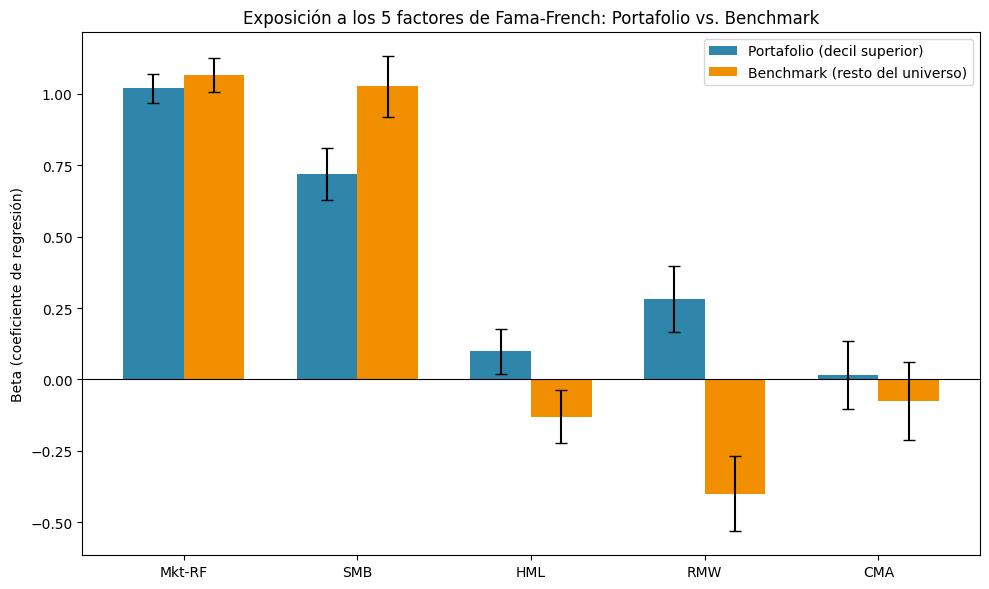

In [12]:
import matplotlib.pyplot as plt
import numpy as np

factores_nombres = ["Mkt-RF", "SMB", "HML", "RMW", "CMA"]

betas_portafolio = modelo_portafolio.params[factores_nombres].values
betas_benchmark  = modelo_benchmark.params[factores_nombres].values

errores_portafolio = modelo_portafolio.bse[factores_nombres].values * 1.96  # IC 95%
errores_benchmark  = modelo_benchmark.bse[factores_nombres].values * 1.96

x = np.arange(len(factores_nombres))
ancho = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - ancho/2, betas_portafolio, ancho, yerr=errores_portafolio,
       label="Portafolio (decil superior)", color="#2E86AB", capsize=4)
ax.bar(x + ancho/2, betas_benchmark, ancho, yerr=errores_benchmark,
       label="Benchmark (resto del universo)", color="#F18F01", capsize=4)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(factores_nombres)
ax.set_ylabel("Beta (coeficiente de regresión)")
ax.set_title("Exposición a los 5 factores de Fama-French: Portafolio vs. Benchmark")
ax.legend()
plt.tight_layout()
plt.savefig("../salidas/grafico_betas_fama_french.png", dpi=150)
plt.show()

Gráfico 2 — crecimiento acumulado con la serie final

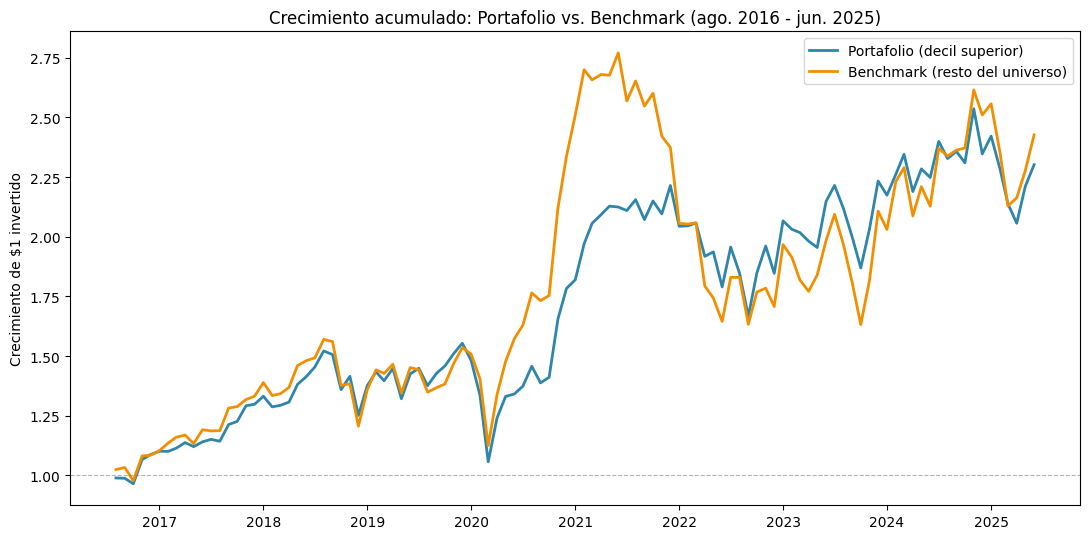

In [13]:
riqueza_portafolio_final = (1 + series_mensuales_filtrado["retorno_portafolio"]).cumprod()
riqueza_benchmark_final  = (1 + series_mensuales_filtrado["retorno_benchmark"]).cumprod()

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(riqueza_portafolio_final.index, riqueza_portafolio_final.values,
        label="Portafolio (decil superior)", color="#2E86AB", linewidth=2)
ax.plot(riqueza_benchmark_final.index, riqueza_benchmark_final.values,
        label="Benchmark (resto del universo)", color="#F18F01", linewidth=2)

ax.axhline(1, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
ax.set_ylabel("Crecimiento de $1 invertido")
ax.set_title("Crecimiento acumulado: Portafolio vs. Benchmark (ago. 2016 - jun. 2025)")
ax.legend()
plt.tight_layout()
plt.savefig("../salidas/grafico_crecimiento_acumulado.png", dpi=150)
plt.show()

HITO 7 — Regresión Fama-French: Portafolio vs. Benchmark

Notebook: 07_retornos_portafolio.ipynb

Qué se hizo:
- Se alinearon las series mensuales de exceso de retorno (retorno menos
  tasa libre de riesgo) del portafolio y del benchmark con los 5
  factores de Fama-French, sobre 107 meses de traslape (agosto 2016 -
  junio 2025).
- Se corrió una regresión OLS independiente para cada grupo:
  Exceso = alpha + b1(Mkt-RF) + b2(SMB) + b3(HML) + b4(RMW) + b5(CMA)

Resultado:
- Ambos modelos presentan un ajuste muy alto (R² ≈ 0.966-0.967): el
  comportamiento de ambos grupos está mayormente explicado por
  exposición a riesgo sistemático conocido.
- Alpha: ninguno de los dos grupos presenta alpha estadísticamente
  significativo al 5% (Portafolio: -0.19% mensual, p=0.095; Benchmark:
  +0.15% mensual, p=0.265) -- no hay evidencia robusta de un exceso
  de retorno no explicado por los factores en ninguno de los dos casos.
- Hallazgo principal -- factor RMW (calidad/rentabilidad): el
  Portafolio presenta una exposición positiva y significativa
  (beta=+0.28, p<0.001), mientras que el Benchmark presenta una
  exposición negativa y significativa (beta=-0.40, p<0.001). Este
  contraste es la evidencia más clara de que el modelo, dentro del
  universo de empresas con FCF negativo, selecciona sistemáticamente
  empresas de mayor calidad fundamental frente a las que descarta,
  en línea con el marco de Quality Minus Junk de Asness et al. (2019).
- El Portafolio también muestra menor exposición a tamaño (SMB=0.72
  vs. 1.03) y una exposición a valor (HML) positiva y leve, frente a
  una exposición negativa del Benchmark -- consistente con seleccionar
  empresas relativamente menos especulativas dentro del universo.

Por qué importa para la tesis:
Responde el Objetivo IV y la Pregunta Secundaria III de forma matizada
y honesta: no se encuentra evidencia de alpha puro tras controlar por
riesgo sistemático, pero sí evidencia sólida de que el modelo
discrimina calidad fundamental (RMW) dentro del universo de empresas
en pérdida -- validando empíricamente la hipótesis de "calidad latente"
en su dimensión de exposición a factores, aunque no en su dimensión
de retorno anormal no explicado.